In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


# Linear Regression

In [2]:
dataset = pd.read_csv('Salary_Data.csv')
print(dataset.shape)
dataset.head()

(30, 2)


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


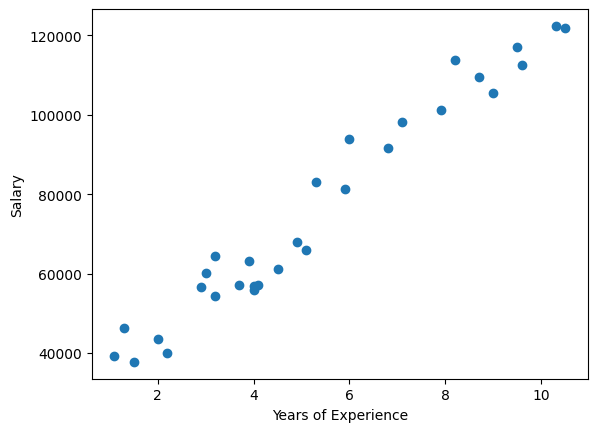

In [4]:
plt.scatter(dataset['YearsExperience'], dataset['Salary'])
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [3]:
X = dataset.iloc[:, 0].values
y = dataset.iloc[:, 1].values

In [7]:
len(X)

30

In [8]:
len(y)

30

### Train test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=0)

In [9]:
len(X_train)

24

In [10]:
len(X_test)

6

### TRAINING

In [13]:
regressor = LinearRegression()
regressor.fit(X_train.reshape(-1, 1), y_train)

LinearRegression()

In [14]:
y_pred = regressor.predict(X_test.reshape(-1, 1))

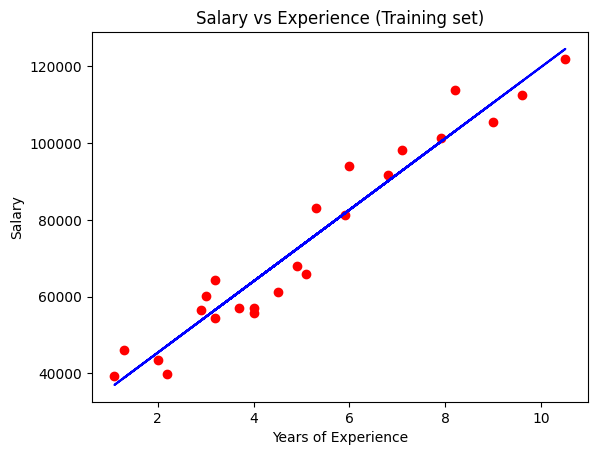

In [15]:
plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, regressor.predict(X_train.reshape(-1, 1)), color='blue')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

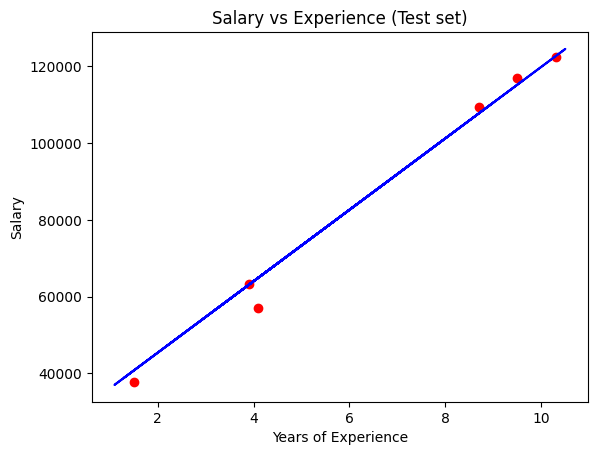

In [19]:
plt.scatter(X_test, y_test, color='red')
plt.plot(X_train, regressor.predict(X_train.reshape(-1, 1)), color='blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [20]:
# R2
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.988169515729126

In [23]:
# RMSE
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse

np.float64(3580.979237321343)

In [24]:
# Create dataframe with X_test, y_test, and y_pred
df = pd.DataFrame({'X_test': X_test, 'y_test': y_test, 'y_pred': y_pred})
df

,X_test,y_test,y_pred
0,1.5,37731.0,40748.961841
1,10.3,122391.0,122699.622956
2,4.1,57081.0,64961.657170
3,3.9,63218.0,63099.142145
4,9.5,116969.0,115249.562855
5,8.7,109431.0,107799.502753


## Multiple Linear Regression

In [25]:
dataset = pd.read_csv('50_Startups.csv')
print(dataset.shape)
dataset.head()

(50, 5)


,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [39]:
dataset.State.value_counts()


,count
State,
New York,17
California,17
Florida,16


In [26]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [27]:
X

array([[165349.2, 136897.8, 471784.1, 'New York'],
       [162597.7, 151377.59, 443898.53, 'California'],
       [153441.51, 101145.55, 407934.54, 'Florida'],
       [144372.41, 118671.85, 383199.62, 'New York'],
       [142107.34, 91391.77, 366168.42, 'Florida'],
       [131876.9, 99814.71, 362861.36, 'New York'],
       [134615.46, 147198.87, 127716.82, 'California'],
       [130298.13, 145530.06, 323876.68, 'Florida'],
       [120542.52, 148718.95, 311613.29, 'New York'],
       [123334.88, 108679.17, 304981.62, 'California'],
       [101913.08, 110594.11, 229160.95, 'Florida'],
       [100671.96, 91790.61, 249744.55, 'California'],
       [93863.75, 127320.38, 249839.44, 'Florida'],
       [91992.39, 135495.07, 252664.93, 'California'],
       [119943.24, 156547.42, 256512.92, 'Florida'],
       [114523.61, 122616.84, 261776.23, 'New York'],
       [78013.11, 121597.55, 264346.06, 'California'],
       [94657.16, 145077.58, 282574.31, 'New York'],
       [91749.16, 114175.79, 29491

In [28]:
y

array([192261.83, 191792.06, 191050.39, 182901.99, 166187.94, 156991.12,
       156122.51, 155752.6 , 152211.77, 149759.96, 146121.95, 144259.4 ,
       141585.52, 134307.35, 132602.65, 129917.04, 126992.93, 125370.37,
       124266.9 , 122776.86, 118474.03, 111313.02, 110352.25, 108733.99,
       108552.04, 107404.34, 105733.54, 105008.31, 103282.38, 101004.64,
        99937.59,  97483.56,  97427.84,  96778.92,  96712.8 ,  96479.51,
        90708.19,  89949.14,  81229.06,  81005.76,  78239.91,  77798.83,
        71498.49,  69758.98,  65200.33,  64926.08,  49490.75,  42559.73,
        35673.41,  14681.4 ])

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [30]:
X

array([[0.0, 0.0, 1.0, 165349.2, 136897.8, 471784.1],
       [1.0, 0.0, 0.0, 162597.7, 151377.59, 443898.53],
       [0.0, 1.0, 0.0, 153441.51, 101145.55, 407934.54],
       [0.0, 0.0, 1.0, 144372.41, 118671.85, 383199.62],
       [0.0, 1.0, 0.0, 142107.34, 91391.77, 366168.42],
       [0.0, 0.0, 1.0, 131876.9, 99814.71, 362861.36],
       [1.0, 0.0, 0.0, 134615.46, 147198.87, 127716.82],
       [0.0, 1.0, 0.0, 130298.13, 145530.06, 323876.68],
       [0.0, 0.0, 1.0, 120542.52, 148718.95, 311613.29],
       [1.0, 0.0, 0.0, 123334.88, 108679.17, 304981.62],
       [0.0, 1.0, 0.0, 101913.08, 110594.11, 229160.95],
       [1.0, 0.0, 0.0, 100671.96, 91790.61, 249744.55],
       [0.0, 1.0, 0.0, 93863.75, 127320.38, 249839.44],
       [1.0, 0.0, 0.0, 91992.39, 135495.07, 252664.93],
       [0.0, 1.0, 0.0, 119943.24, 156547.42, 256512.92],
       [0.0, 0.0, 1.0, 114523.61, 122616.84, 261776.23],
       [1.0, 0.0, 0.0, 78013.11, 121597.55, 264346.06],
       [0.0, 0.0, 1.0, 94657.16, 145077.58

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=0)

In [41]:
regressor = LinearRegression()

In [42]:
regressor.fit(X_train, y_train)

LinearRegression()

In [43]:
y_pred = regressor.predict(X_test)

In [44]:
# R2
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9347068473282546

In [46]:
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred), 1),
                      y_test.reshape(len(y_test), 1)),
                      1))

[[103015.2  103282.38]
 [132582.28 144259.4 ]
 [132447.74 146121.95]
 [ 71976.1   77798.83]
 [178537.48 191050.39]
 [116161.24 105008.31]
 [ 67851.69  81229.06]
 [ 98791.73  97483.56]
 [113969.44 110352.25]
 [167921.07 166187.94]]


Text(0, 0.5, 'Residuals')

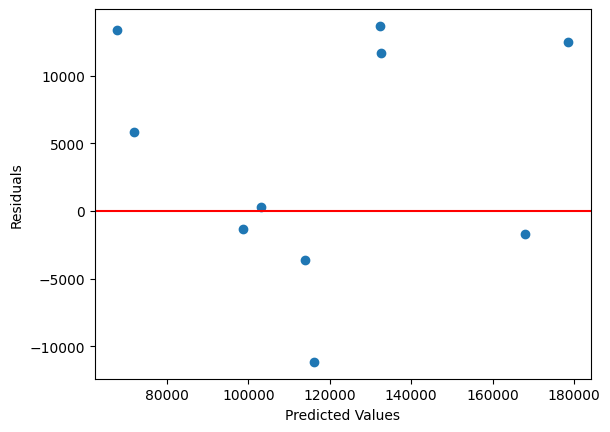

In [48]:
# Plot residual errors with red line at 0
plt.scatter(y_pred, y_test - y_pred)
plt.axhline(y=0, color='r', linestyle='-')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')


# Polynomial regression

In [49]:
dataset = pd.read_csv('Position_Salaries.csv')
print(dataset.shape)
dataset.head()

(10, 3)


,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [50]:
X = dataset.iloc[:, 1].values
y = dataset.iloc[:, 2].values

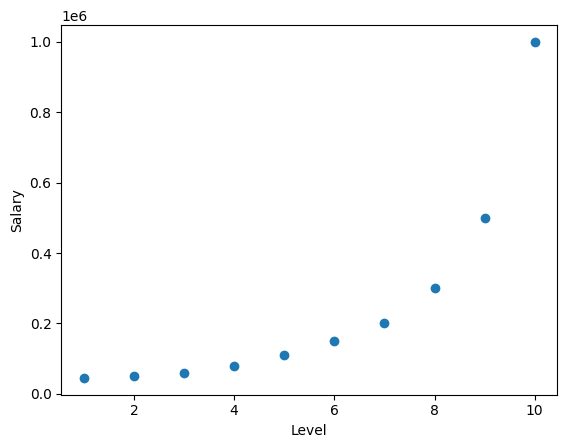

In [51]:
plt.scatter(X, y)
plt.xlabel('Level')
plt.ylabel('Salary')
plt.show()

In [53]:
lin_reg = LinearRegression()
lin_reg.fit(X.reshape(-1, 1), y)

LinearRegression()

In [54]:
X

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [75]:
poly_reg = PolynomialFeatures(degree=2)
X_poly = poly_reg.fit_transform(X.reshape(-1, 1))


In [76]:
X_poly

array([[  1.,   1.,   1.],
       [  1.,   2.,   4.],
       [  1.,   3.,   9.],
       [  1.,   4.,  16.],
       [  1.,   5.,  25.],
       [  1.,   6.,  36.],
       [  1.,   7.,  49.],
       [  1.,   8.,  64.],
       [  1.,   9.,  81.],
       [  1.,  10., 100.]])

In [77]:
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)

LinearRegression()

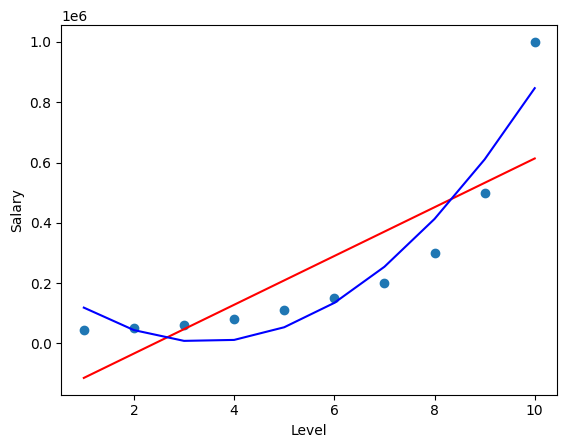

In [78]:
plt.scatter(X, y)
plt.plot(X, lin_reg.predict(X.reshape(-1, 1)), color='red')
plt.plot(X, lin_reg_2.predict(X_poly), color = 'blue')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.show()